# D7 on D7b: Cascade + Tumor Oversample + Tversky-only under Label Noise
## Benchmarking Noise-Robust Training Strategies for Liver Tumor Segmentation on LiTS

**Strategy under test:** D7b — two-stage cascade (frozen D6c-v2 for liver, new Stage-2 net for tumor inside liver crop) + 3:1 tumor oversampling + Tversky-only loss.

**Where the noise applies:** Stage-2 only. Stage-1 is the *frozen, clean* D6c-v2 checkpoint — noise can't touch it. We corrupt the **binary** tumor labels that Stage-2 sees (0=non-tumor, 1=tumor).

**One run, single config:** combined @ 50%. Cell 1 has knobs for later.

## Prerequisites

1. `lits_core.py` and `lits_cascade.py` next to this notebook.
2. `./out_d6c_v2/best_unet_d6c_v2.pth` — your **CLEAN** D6c-v2 checkpoint. Use the clean one, not a noisy one — Stage-1 should be the best liver segmenter you've got.


## 1. Noise Configuration

In [1]:
# CELL 1
NOISE_TYPE = 'combined'    # 'missing' | 'jitter' | 'combined' | None
NOISE_RATE = 0.50

STRATEGY     = 'D7b'
NOISE_SEED   = 2026          # KEEP CONSTANT across all D7 strategies
RESULTS_FILE = f'results_d7_{STRATEGY}.json'

config_tag = (
    f'{STRATEGY}__clean' if NOISE_TYPE is None
    else f'{STRATEGY}__{NOISE_TYPE}_r{int(round(NOISE_RATE*100)):02d}'
)
print(f'Config: {config_tag}')


Config: D7b__combined_r50


## 2. Imports

In [2]:
import os, sys, json, time, copy, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

sys.path.insert(0, '.')
from lits_core import (get_device, load_lits_paths, make_split,
                       LiTS25DDataset, UNet2D, compute_dice_per_class)
from lits_cascade import (combined_tversky_loss, tversky_loss,
                          LiTSLiverCroppedDataset, liver_bbox,
                          stage1_predict_liver_mask,
                          make_tumor_oversampler)

from scipy import ndimage

DEVICE = get_device()
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')


Device: cuda | PyTorch: 2.11.0+cu128


## 3. Configuration (matches D7b)

In [3]:
DATA_DIR    = '/home/adnan/aeman_dl/archive-2'
OUT_DIR     = './out_d7_d7b'
TAG         = config_tag

IMG_SIZE    = 128
STACK_SIZE  = 5

STAGE1_CKPT      = './out_d6c_v2/best_unet_d6c_v2.pth'
STAGE1_DROPOUT_P = 0.3

S2_BATCH      = 16
S2_NUM_EPOCHS = 30
S2_LR         = 1e-4
S2_WD         = 1e-5
S2_ETA_MIN    = 1e-7
S2_PAD_FRAC   = 0.05
S2_TVERSKY_A  = 0.3
S2_TVERSKY_B  = 0.7
S2_AUG        = True
S2_AUG_STR    = 'medium'

OVERSAMPLE_RATIO = 3.0

os.makedirs(OUT_DIR, exist_ok=True)
print(f'Stage-1: {STAGE1_CKPT}')
print(f'Stage-2: {S2_NUM_EPOCHS} epochs | bs={S2_BATCH} | cosine {S2_LR}->{S2_ETA_MIN}')
print(f'Tversky alpha={S2_TVERSKY_A} beta={S2_TVERSKY_B}')
print(f'Oversample: {OVERSAMPLE_RATIO}x')


Stage-1: ./out_d6c_v2/best_unet_d6c_v2.pth
Stage-2: 30 epochs | bs=16 | cosine 0.0001->1e-07
Tversky alpha=0.3 beta=0.7
Oversample: 3.0x


## 4. Load Volumes + Split

In [4]:
volume_paths, seg_paths = load_lits_paths(DATA_DIR)
train_v, train_s, val_v, val_s, test_v, test_s = make_split(
    volume_paths, seg_paths, seed=SEED)


Found 51 matched volume-segmentation pairs
Split — Train: 35 | Val: 8 | Test: 8


## 5. Stage-1 (D6c-v2, frozen) — clean checkpoint

Stage-1 stays clean across all noise experiments. Its job is liver localization, which we trust to be solid. Our research question is how Stage-2 (the tumor segmenter) tolerates noisy tumor labels.


In [5]:
stage1 = UNet2D(in_channels=STACK_SIZE, num_classes=3, base_features=64,
                use_attention=False).to(DEVICE)
original_bn = stage1.bottleneck
stage1.bottleneck = nn.Sequential(
    original_bn, nn.Dropout2d(p=STAGE1_DROPOUT_P)).to(DEVICE)

if not os.path.exists(STAGE1_CKPT):
    raise FileNotFoundError(
        f'Stage-1 checkpoint not found at {STAGE1_CKPT}. '
        f'Run your clean d6c_v2_cosine_dropout.ipynb first.'
    )

state = torch.load(STAGE1_CKPT, map_location=DEVICE)
stage1.load_state_dict(state)
stage1.eval()
for p in stage1.parameters():
    p.requires_grad = False
print(f'Stage-1 loaded. Params: {sum(p.numel() for p in stage1.parameters()):,} (frozen)')


Stage-1 loaded. Params: 31,038,915 (frozen)


## 6. NoisyBinaryWrapper — Slice-Level Noise on Binary Tumor Masks

`LiTSLiverCroppedDataset` returns binary masks (0 = non-tumor, 1 = tumor inside the liver crop). lits_core's noise functions assume 3-class masks, so we wrap with this small class.

The mechanism mirrors `LiTS25DDataset._corrupt_label`:
- Each slice independently rolled with prob `noise_rate`
- For chosen slices, `combined` randomly picks `missing` or `jitter`
- `missing` — wipe all tumor pixels (tumor → non-tumor)
- `jitter` — dilate or erode tumor boundary 1–3 px

Same `noise_seed` → same exact corrupted slices, just like the multi-class case.


In [6]:
class NoisyBinaryWrapper(Dataset):
    """Wraps a dataset returning (ct_stack, binary_mask) and applies noise.

    Binary mask convention: 0 = non-tumor (background or liver), 1 = tumor.
    Noise applies AFTER any internal augmentation in the wrapped dataset.
    Slice-level noise (matches lits_core's mechanism for the 3-class case).
    """

    def __init__(self, base_dataset, noise_type=None, noise_rate=0.0,
                 noise_seed=2026):
        assert noise_type in (None, 'missing', 'jitter', 'combined')
        self.base = base_dataset
        self.noise_type = noise_type
        self.noise_rate = noise_rate

        n = len(base_dataset)
        rng = np.random.RandomState(noise_seed)
        self._noisy_mask  = rng.rand(n) < noise_rate if noise_type else np.zeros(n, dtype=bool)
        self._noisy_kinds = rng.choice(['missing', 'jitter'], size=n)
        self._noisy_seeds = rng.randint(0, 1_000_000, size=n)

        n_noisy = int(self._noisy_mask.sum())
        print(f'NoisyBinaryWrapper: {n} slices | noise={noise_type}@{noise_rate:.0%} '
              f'({n_noisy} slices marked)')

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        ct, seg = self.base[idx]
        if not self._noisy_mask[idx] or self.noise_type is None:
            return ct, seg

        # Convert to numpy for corruption
        if isinstance(seg, torch.Tensor):
            seg_np = seg.detach().cpu().numpy().astype(np.int64)
            return_tensor = True
        else:
            seg_np = np.asarray(seg, dtype=np.int64)
            return_tensor = False

        kind = (self._noisy_kinds[idx] if self.noise_type == 'combined'
                else self.noise_type)
        seed = int(self._noisy_seeds[idx])
        rng = np.random.RandomState(seed)

        tumor = (seg_np == 1)
        if not tumor.any():
            return ct, seg

        if kind == 'missing':
            seg_np[tumor] = 0  # wipe all tumor pixels in this slice

        else:  # jitter
            iters = int(rng.randint(1, 4))
            if rng.rand() < 0.5:
                # dilate: non-tumor pixels next to tumor become tumor
                dilated = ndimage.binary_dilation(tumor, iterations=iters)
                grew = dilated & (~tumor)
                seg_np[grew] = 1
            else:
                # erode: tumor edges become non-tumor
                eroded = ndimage.binary_erosion(tumor, iterations=iters)
                lost = tumor & (~eroded)
                seg_np[lost] = 0

        if return_tensor:
            return ct, torch.from_numpy(seg_np)
        return ct, seg_np


## 7. Build Stage-2 Datasets — Noisy Train, Clean Val

In [7]:
print('Building Stage-2 train (cropped, aug=ON)...')
s2_train_clean = LiTSLiverCroppedDataset(
    train_v, train_s, img_size=IMG_SIZE, stack_size=STACK_SIZE,
    pad_frac=S2_PAD_FRAC, augment=S2_AUG, aug_strength=S2_AUG_STR)

s2_train = NoisyBinaryWrapper(
    s2_train_clean, noise_type=NOISE_TYPE,
    noise_rate=NOISE_RATE if NOISE_TYPE else 0.0,
    noise_seed=NOISE_SEED,
)

print('\nBuilding Stage-2 val (cropped, aug=OFF, clean)...')
s2_val = LiTSLiverCroppedDataset(
    val_v, val_s, img_size=IMG_SIZE, stack_size=STACK_SIZE,
    pad_frac=S2_PAD_FRAC, augment=False)

# Tumor oversampling (D7b's other knob)
sampler = make_tumor_oversampler(s2_train_clean, ratio=OVERSAMPLE_RATIO)

s2_train_loader = DataLoader(s2_train, batch_size=S2_BATCH, sampler=sampler,
                             num_workers=0, pin_memory=False)
s2_val_loader   = DataLoader(s2_val,   batch_size=S2_BATCH, shuffle=False,
                             num_workers=0, pin_memory=False)
print(f'\nTrain batches: {len(s2_train_loader)} | Val batches: {len(s2_val_loader)}')


Building Stage-2 train (cropped, aug=ON)...
CroppedDataset: 4614 slices (1594 with tumor, 3020 liver-only) | skipped 8101 bg-only | stack=5 | augment=True (medium)
NoisyBinaryWrapper: 4614 slices | noise=combined@50% (2265 slices marked)

Building Stage-2 val (cropped, aug=OFF, clean)...
CroppedDataset: 1116 slices (327 with tumor, 789 liver-only) | skipped 1474 bg-only | stack=5 | augment=False (medium)
Oversampler: ratio=3.0x | 1594 tumor + 3020 liver-only -> effective 61.3% tumor in each batch

Train batches: 289 | Val batches: 70


## 8. Sanity Check — Visualize Noisy Cropped Slices

Noisy slices: 2265 / 4614
CroppedDataset: 4614 slices (1594 with tumor, 3020 liver-only) | skipped 8101 bg-only | stack=5 | augment=False (medium)


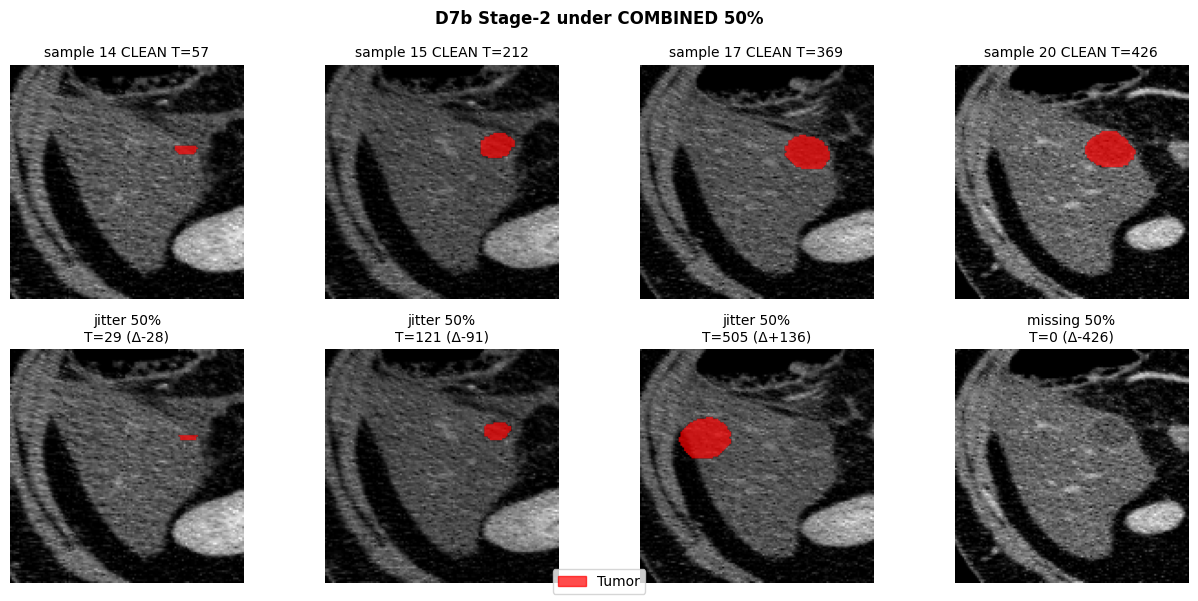

In [8]:
if NOISE_TYPE is None:
    print('Clean run.')
else:
    noisy_idxs = np.where(s2_train._noisy_mask)[0]
    print(f'Noisy slices: {len(noisy_idxs)} / {len(s2_train)}')

    # We need a CLEAN cropped dataset for comparison (same indexing, no noise)
    s2_train_for_viz = LiTSLiverCroppedDataset(
        train_v, train_s, img_size=IMG_SIZE, stack_size=STACK_SIZE,
        pad_frac=S2_PAD_FRAC, augment=False)   # aug off so we compare like-for-like

    show = []
    for i in noisy_idxs[:200]:
        _, m = s2_train_for_viz[int(i)]
        if (m == 1).sum().item() > 30:
            show.append(int(i))
        if len(show) >= 4:
            break

    if show:
        center = STACK_SIZE // 2
        fig, axes = plt.subplots(2, len(show), figsize=(3.2 * len(show), 6))
        if len(show) == 1: axes = axes[:, None]
        for col, i in enumerate(show):
            ct_clean, mc_clean = s2_train_for_viz[i]
            mc_np = mc_clean.numpy()
            # Re-fetch noisy via wrapper (note: aug ON so it may not align perfectly,
            # but the corruption pattern is what we care about)
            _, mn = s2_train[i]
            mn_np = mn.numpy() if isinstance(mn, torch.Tensor) else mn
            ct_img = ct_clean[center].numpy()

            for row, (m, label) in enumerate([(mc_np, 'CLEAN'), (mn_np, 'NOISY')]):
                ov = np.zeros((*ct_img.shape, 4))
                ov[m == 1] = [1, 0, 0, 0.7]   # tumor only
                axes[row, col].imshow(ct_img.T, cmap='gray', origin='lower')
                axes[row, col].imshow(ov.transpose(1, 0, 2), origin='lower')
                t_px = (m == 1).sum()
                if row == 0:
                    title = f'sample {i} CLEAN T={t_px}'
                else:
                    delta = int(t_px - (mc_np == 1).sum())
                    kind = s2_train._noisy_kinds[i] if NOISE_TYPE == 'combined' else NOISE_TYPE
                    title = f'{kind} {NOISE_RATE:.0%}\nT={t_px} (Δ{delta:+})'
                axes[row, col].set_title(title, fontsize=10)
                axes[row, col].axis('off')

        red = mpatches.Patch(color='red', alpha=0.7, label='Tumor')
        fig.legend(handles=[red], loc='lower center')
        plt.suptitle(f'{STRATEGY} Stage-2 under {NOISE_TYPE.upper()} {NOISE_RATE:.0%}',
                     fontweight='bold')
        plt.tight_layout(); plt.show()


## 9. Build Stage-2 Model

In [9]:
s2_model = UNet2D(in_channels=STACK_SIZE, num_classes=2, base_features=64,
                  use_attention=False).to(DEVICE)
n_params = sum(p.numel() for p in s2_model.parameters() if p.requires_grad)
print(f'Stage-2 model: in_ch={STACK_SIZE}, num_classes=2 (binary), params={n_params:,}')


Stage-2 model: in_ch=5, num_classes=2 (binary), params=31,038,850


## 10. Train Stage-2 — Tversky-only + Cosine LR

Same training recipe as your clean D7b. Validation uses **clean cropped val set**.


In [10]:
torch.manual_seed(SEED)

optimizer = torch.optim.Adam(s2_model.parameters(), lr=S2_LR, weight_decay=S2_WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=S2_NUM_EPOCHS, eta_min=S2_ETA_MIN)

history = {k: [] for k in
           ['train_loss', 'val_loss', 'val_tumor_dice', 'epoch_mins', 'lr']}
best_tumor = 0.0
best_state = None


def tumor_dice_binary(preds, targets, smooth=1e-6):
    pred_cls = preds.argmax(dim=1)
    p = (pred_cls == 1).float()
    t = (targets == 1).float()
    inter = (p * t).sum()
    denom = p.sum() + t.sum()
    return ((2 * inter + smooth) / (denom + smooth)).item() if denom > 0 else 1.0


print('=' * 78)
print(f'TRAINING: {TAG}  (cascade + oversample + Tversky-only + noise)')
print(f'  Epochs={S2_NUM_EPOCHS} | cosine {S2_LR}->{S2_ETA_MIN}')
print(f'  Tversky alpha={S2_TVERSKY_A} beta={S2_TVERSKY_B}')
print('=' * 78)

run_start = time.time()
for epoch in range(1, S2_NUM_EPOCHS + 1):
    t0 = time.time()
    current_lr = optimizer.param_groups[0]['lr']

    s2_model.train()
    train_losses = []
    for bi, (ct, seg) in enumerate(s2_train_loader):
        ct, seg = ct.to(DEVICE), seg.to(DEVICE)
        optimizer.zero_grad()
        preds = s2_model(ct)
        loss = tversky_loss(preds, seg, num_classes=preds.shape[1],
                            alpha=S2_TVERSKY_A, beta=S2_TVERSKY_B)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        if (bi + 1) % 100 == 0:
            print(f'  ep {epoch:02d} batch {bi+1}/{len(s2_train_loader)} loss={loss.item():.4f}')

    s2_model.eval()
    val_losses, tumors = [], []
    with torch.no_grad():
        for ct, seg in s2_val_loader:
            ct, seg = ct.to(DEVICE), seg.to(DEVICE)
            preds = s2_model(ct)
            val_losses.append(tversky_loss(
                preds, seg, num_classes=preds.shape[1],
                alpha=S2_TVERSKY_A, beta=S2_TVERSKY_B).item())
            tumors.append(tumor_dice_binary(preds, seg))

    m_train = float(np.mean(train_losses))
    m_val   = float(np.mean(val_losses))
    m_tumor = float(np.mean(tumors))
    em = (time.time() - t0) / 60

    for k, v in [('train_loss', m_train), ('val_loss', m_val),
                 ('val_tumor_dice', m_tumor),
                 ('epoch_mins', em), ('lr', current_lr)]:
        history[k].append(v)

    scheduler.step()

    flag = ''
    if m_tumor > best_tumor:
        best_tumor = m_tumor
        best_state = {k: v.cpu().clone() for k, v in s2_model.state_dict().items()}
        flag = ' *** BEST'

    print(f'Ep {epoch:02d}/{S2_NUM_EPOCHS} | {em:4.1f}min | LR={current_lr:.2e} | '
          f'Train: {m_train:.4f} | Val: {m_val:.4f} | Tumor: {m_tumor:.4f}{flag}')

run_mins = (time.time() - run_start) / 60

best_idx = int(np.argmax(history['val_tumor_dice']))
best_tumor_dice = float(history['val_tumor_dice'][best_idx])
best_epoch = best_idx + 1

ckpt = os.path.join(OUT_DIR, f'best_stage2_{config_tag}.pth')
torch.save(best_state, ckpt)
print(f'\nBest: tumor={best_tumor_dice:.4f} @ epoch {best_epoch}')
print(f'Total time: {run_mins:.1f} min  |  Checkpoint: {ckpt}')
print(f'\nNOTE: this is the binary tumor Dice on the cropped val set ("oracle bbox").')
print(f'It is NOT directly comparable to the multi-class tumor Dice from D4/D6c.')


TRAINING: D7b__combined_r50  (cascade + oversample + Tversky-only + noise)
  Epochs=30 | cosine 0.0001->1e-07
  Tversky alpha=0.3 beta=0.7
  ep 01 batch 100/289 loss=0.7176
  ep 01 batch 200/289 loss=0.6256
Ep 01/30 |  2.8min | LR=1.00e-04 | Train: 0.7781 | Val: 0.9396 | Tumor: 0.1637 *** BEST
  ep 02 batch 100/289 loss=0.7429
  ep 02 batch 200/289 loss=0.6480
Ep 02/30 |  2.5min | LR=9.97e-05 | Train: 0.5816 | Val: 0.9123 | Tumor: 0.2239 *** BEST
  ep 03 batch 100/289 loss=0.5558
  ep 03 batch 200/289 loss=0.3820
Ep 03/30 |  2.5min | LR=9.89e-05 | Train: 0.4596 | Val: 0.8854 | Tumor: 0.1777
  ep 04 batch 100/289 loss=0.8110
  ep 04 batch 200/289 loss=0.1711
Ep 04/30 |  2.5min | LR=9.76e-05 | Train: 0.3724 | Val: 0.8760 | Tumor: 0.4389 *** BEST
  ep 05 batch 100/289 loss=0.1708
  ep 05 batch 200/289 loss=0.2108
Ep 05/30 |  2.5min | LR=9.57e-05 | Train: 0.3440 | Val: 0.8782 | Tumor: 0.3388
  ep 06 batch 100/289 loss=0.3167
  ep 06 batch 200/289 loss=0.3249
Ep 06/30 |  2.5min | LR=9.33e-0

## 11. Save Result to JSON

In [11]:
results_path = Path(RESULTS_FILE)
results = json.load(results_path.open()) if results_path.exists() else {}

results[config_tag] = {
    'strategy':        STRATEGY,
    'noise_type':      NOISE_TYPE,
    'noise_rate':      NOISE_RATE if NOISE_TYPE else 0.0,
    'noise_seed':      NOISE_SEED,
    'tumor_dice':      best_tumor_dice,
    'best_epoch':      best_epoch,
    'history':         history,
    'num_epochs':      S2_NUM_EPOCHS,
    'run_minutes':     float(run_mins),
    'stack_size':      STACK_SIZE,
    'oversample_ratio': OVERSAMPLE_RATIO,
    'tversky_alpha':   S2_TVERSKY_A,
    'tversky_beta':    S2_TVERSKY_B,
    'metric_note':     'binary tumor Dice on oracle-cropped val set',
}

results_path.write_text(json.dumps(results, indent=2, default=str))
print(f'Saved {config_tag} to {RESULTS_FILE}')
print(f'\nAll entries:')
for k, v in sorted(results.items()):
    print(f'  {k:30s}  tumor={v["tumor_dice"]:.4f}')


Saved D7b__combined_r50 to results_d7_D7b.json

All entries:
  D7b__combined_r50               tumor=0.5636
